# 08 — Peak maps

In [1]:
import sys; sys.path.insert(0, "utils")
from config import *

import re
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from nilearn import image, plotting
from scipy.spatial import cKDTree
warnings.filterwarnings("ignore", category=FutureWarning)

# Peak maps are rendered only for the no-volume-covariate LNM group comparison (lnm_nocov):
# cohort fixed effects + within-cohort exchangeability blocks.
MAIN_FAMILY = CORE_FAMILY

# Pretty family name for headings and legends.
FAMILY_PRETTY = {FAM_LNM_NOCOV: "LNM — no volume covariate"}

# Per-domain colours (fixed display order from config.KEYS / config.NAMES).
COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]

print("PROJECT_ROOT :", PROJECT_ROOT)
print("FIG_DIR      :", FIG_DIR)
print("family       :", MAIN_FAMILY, "->", FAMILY_PRETTY[MAIN_FAMILY])
fin = [DOMAINS[k] for k in KEYS if has_results(MAIN_FAMILY, k)]
print(f"finished {len(fin)}/{len(KEYS)} domains")

PROJECT_ROOT : .
FIG_DIR      : output/figures
family       : lnm_nocov -> LNM — no volume covariate
finished 6/6 domains


## Mask, connectome degree map, atlases and peak helpers

In [2]:
# Brain mask + affine (via config helper), and the connectome degree map for percentiles.
brain, affine, bg_path = load_mask()
mask = brain
mask_img = nib.Nifti1Image(mask.astype(np.uint8), affine)

degree = nib.load(DEGREE_MAP).get_fdata()
degree_in = degree[mask]

def degree_pctile(idx):
    """Percentile of the connectome degree at a voxel among all in-mask voxels."""
    return float((degree_in < degree[idx]).mean() * 100)

# Label peaks with the SAME atlas used by the connectome / simulation:
# Schaefer-1000 (cortical) + Tian S4 / Melbourne-54 (subcortical), resampled to the analysis grid.
# Atlas integer value v -> labels[v-1] (1-indexed).
ATLAS_DIR = DATA_DIR / "atlases"
sch_img = image.resample_to_img(
    str(ATLAS_DIR / "Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_1mm.nii.gz"),
    mask_img, interpolation="nearest", force_resample=True, copy_header=True)
tian_img = image.resample_to_img(
    str(ATLAS_DIR / "Tian_Subcortex_S4_3T_1mm.nii.gz"),
    mask_img, interpolation="nearest", force_resample=True, copy_header=True)
# Buckner 7-network cerebellar atlas, used only as a cerebellum MASK. Without it, cerebellar
# peaks fall through to the nearest CORTICAL parcel (a visual parcel) and are mislabelled.
buck_img = image.resample_to_img(
    str(ATLAS_DIR / "Buckner7.nii.gz"),
    mask_img, interpolation="nearest", force_resample=True, copy_header=True)
sch = sch_img.get_fdata().astype(int)
tian = tian_img.get_fdata().astype(int)
buck = buck_img.get_fdata().astype(int)
sch_lab = np.loadtxt(ATLAS_DIR / "Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_1mm_labels.txt", dtype=str)
tian_lab = np.loadtxt(ATLAS_DIR / "Tian_Subcortex_S4_3T_1mm_labels.txt", dtype=str)
print("Schaefer parcels:", len(sch_lab), "| Tian parcels:", len(tian_lab),
      "| Buckner used as a cerebellum mask")

def _direct_label(idx):
    """Label exactly at a voxel: Tian subcortex, then cerebellum, then Schaefer cortex."""
    i, j, k = idx
    if tian[i, j, k] > 0:
        return f"{tian_lab[tian[i, j, k] - 1]} (Tian subcortex)"
    if buck[i, j, k] > 0:                          # Buckner used only as a cerebellum mask
        return "Cerebellum"
    if sch[i, j, k] > 0:
        return sch_lab[sch[i, j, k] - 1]
    return None

# KD-tree over all labelled voxels (in MNI mm) for a nearest-parcel fallback, so peaks that
# fall in deep white matter still get an informative "near <parcel>" label.
_lab_idx = np.argwhere((sch > 0) | (tian > 0) | (buck > 0))
_lab_mni = nib.affines.apply_affine(affine, _lab_idx)
_tree = cKDTree(_lab_mni)

def anat_label(idx):
    direct = _direct_label(idx)
    if direct is not None:
        return direct
    coord = nib.affines.apply_affine(affine, idx)
    d, nn = _tree.query(coord)
    near = _direct_label(tuple(_lab_idx[nn]))
    if near == "Cerebellum":                       # cerebellar white matter -> just "Cerebellum"
        return "Cerebellum"
    return f"deep white matter (nearest: {near}, {d:.0f} mm)"

Schaefer parcels: 1000 | Tian parcels: 54 | Buckner used as a cerebellum mask


### Signed T-map, significance map and peak finding

Peaks are located on the **full, unmasked** signed T-map (`F_TSTAT`), regardless of
significance: `signed_t(family, key)` returns the in-brain signed T (out-of-brain voxels
zeroed), and `sig_mask(family, key)` returns the permutation TFCE-FDR significance mask
(`F_PERM_FDR >= THR`, -log10(p) maps so >= THR means p <= 0.05). Peak-finding runs on the signed
T; each peak then gets a boolean `significant` flag by looking up `sig_mask` at the peak voxel.

> Method note: greedy local maxima of the signed T within the brain mask, restricted to one
> sign, with a >= 20 mm minimum spacing — the reference peak algorithm. We do **not** restrict
> to significant voxels; instead each of the top-5 ± peaks is shown regardless of significance,
> with significance (permutation pFDR < 0.05) carried as a per-peak flag. This guarantees every
> domain shows its strongest ± effects even when none survive correction.

In [3]:
def signed_t(family, key):
    """Full signed T-map (F_TSTAT) for a family, in-brain voxels only (out-of-brain zeroed)."""
    return load_map(family, key, F_TSTAT, brain=brain)

def sig_mask(family, key):
    """Permutation TFCE-FDR significance mask (F_PERM_FDR >= THR, i.e. p <= 0.05) for a family."""
    return load_map(family, key, F_PERM_FDR, brain=brain) >= THR

def find_peaks(tmap, sign, sig=None, n=5, min_sep_mm=20.0):
    """Greedy local maxima of SIGNED T within the mask, restricted to one sign.

    sign = +1 -> positive peaks (largest +T); sign = -1 -> negative peaks (most negative T).
    Peaks are >= min_sep_mm apart. Operates on the FULL (unmasked) signed T-map, so peaks are
    found regardless of significance. If `sig` (a boolean significance mask) is given, each peak
    carries its significance flag.
    Returns list of (mni_coord, voxel_idx, signed_T, significant_bool)."""
    signed = tmap * sign                                   # rank this descending
    a = np.where(mask & (signed > 0), signed, -np.inf)     # keep only the requested sign
    order = np.argsort(a, axis=None)[::-1]
    coords_idx = np.array(np.unravel_index(order, a.shape)).T
    chosen = []
    for idx in coords_idx:
        if a[tuple(idx)] == -np.inf:
            break
        coord = nib.affines.apply_affine(affine, idx)
        if all(np.linalg.norm(coord - c) >= min_sep_mm for c, _, _, _ in chosen):
            t = tuple(int(v) for v in idx)
            is_sig = bool(sig[t]) if sig is not None else False
            chosen.append((coord, t, float(tmap[t]), is_sig))
        if len(chosen) >= n:
            break
    return chosen

def _proj2d(direction, c):
    """MNI mm -> 2D coords on a glass-brain view (axis limits handle L/R orientation)."""
    x, y, z = c
    if direction == "y":          # coronal
        return x, z
    if direction == "z":          # axial
        return x, y
    return y, z                   # sagittal (x / l / r)

def add_markers_swapsag(disp, coords, sizes, color, ranks=None, edgecolor="black",
                        sig=None):
    """Draw markers on a 'lyrz' glass brain, but with the two SAGITTAL panels' hemispheres
    swapped: left-hemisphere peaks (x<0) shown in the right ('r') sagittal and right-hemisphere
    peaks (x>0) in the left ('l') sagittal, rendering each hemisphere as a conventional lateral
    view. Coronal/axial panels are unchanged. Optionally numbers the dots.

    `sig` is accepted for call-site compatibility but does NOT affect colour: all dots
    (significant and non-significant alike) are drawn in the full domain `color`.
    Significance is conveyed solely by the `(n.s.)` tag in the per-peak caption."""
    coords = np.atleast_2d(coords)
    sizes = np.atleast_1d(sizes).astype(float)
    for slicer in disp.axes.values():
        sax, d = slicer.ax, slicer.direction
        for i, c in enumerate(coords):
            if (d == "l" and c[0] < 0) or (d == "r" and c[0] > 0):
                continue          # swapped hemisphere assignment for the sagittals
            tx, ty = _proj2d(d, c)
            sax.scatter([tx], [ty], s=sizes[i % sizes.size], facecolors=color,
                        edgecolors=edgecolor, linewidths=0.8, zorder=1000, clip_on=True)
            if ranks is not None:
                sax.text(tx, ty, str(ranks[i]), ha="center", va="center", fontsize=10,
                         color="white", fontweight="bold", zorder=1001, clip_on=True)

## Per-analysis rendering routine

In [4]:
SIGNS = [(+1, "positive"), (-1, "negative")]

def _clean(p):
    return p.replace(" (Tian subcortex)", "").replace("7Networks_", "").replace("_", " ")

def short_struct(lbl):
    """Compact anatomical label for the per-panel caption."""
    if lbl.startswith("deep white matter"):
        return "WM ~ " + _clean(re.search(r"nearest: (.+?), \d+ mm", lbl).group(1))
    return _clean(lbl)


def render_family(family):
    """Render the full peak analysis (table + 3 figure kinds) for one analysis family.

    Writes per-family outputs:
      peaks_<family>_table.csv
      peaks_<family>_global.png
      peaks_<family>_top5_positive_per_domain.png / _top5_negative_per_domain.png
      peaks_<family>_<domain_key>.png   (one per finished domain)
    Returns the family's per-peak DataFrame. Aesthetics + (n.s.) tagging unchanged across families.
    """
    print(f"================  {family} ({FAMILY_PRETTY.get(family, family)})  ================")
    finished = [k for k in KEYS if has_results(family, k)]
    if not finished:
        print(f"  no finished domains for {family} — skipping.")
        return pd.DataFrame()

    # ---- per-peak table -------------------------------------------------------------------
    rows = []
    global_peaks = {"positive": {}, "negative": {}}   # sign -> key -> (mni coord, significant?)
    for key in finished:
        tmap = signed_t(family, key)
        sig = sig_mask(family, key)
        for sign, sname in SIGNS:
            pk = find_peaks(tmap, sign, sig=sig, n=5, min_sep_mm=20.0)
            if not pk:
                print(f"  note: no {sname} peaks for {DOMAINS[key]}")
                continue
            global_peaks[sname][key] = (pk[0][0], pk[0][3])
            n_sig = sum(s for *_, s in pk)
            print(f"  {DOMAINS[key]} / {sname}: {len(pk)} peaks, {n_sig} significant")
            for rank, (coord, idx, tv, is_sig) in enumerate(pk, start=1):
                rows.append({
                    "family": family,
                    "domain": DOMAINS[key],
                    "domain_key": key,
                    "sign": sname,
                    "peak_rank": rank,
                    "is_global_peak": rank == 1,
                    "significant": is_sig,
                    "MNI_x": round(float(coord[0]), 1),
                    "MNI_y": round(float(coord[1]), 1),
                    "MNI_z": round(float(coord[2]), 1),
                    "T_value": round(tv, 2),
                    "abs_T": round(abs(tv), 2),
                    "degree_pctile": round(degree_pctile(idx), 1),
                    "anatomical_label": anat_label(idx),
                })

    peaks_table = pd.DataFrame(rows)
    if not peaks_table.empty:
        out_csv = FIG_DIR / f"peaks_{family}_table.csv"
        peaks_table.to_csv(out_csv, index=False)
        print("wrote", out_csv)
        gp = peaks_table[peaks_table.is_global_peak]
        for sname in ("positive", "negative"):
            sub = gp[gp.sign == sname]
            if sub.empty:
                continue
            print(f"\nGlobal {sname} peaks (rank-1, max {'+T' if sname=='positive' else '-T'}) per domain:")
            print(sub[["domain", "MNI_x", "MNI_y", "MNI_z", "T_value",
                       "significant", "degree_pctile", "anatomical_label"]].to_string(index=False))
        # mean degree percentile of positive vs negative peaks
        print("\nMean connectome-degree percentile of peaks:")
        for scope, df in [("global (rank-1) peaks", gp), ("all top-5 peaks", peaks_table)]:
            pos = df[df.sign == "positive"].degree_pctile
            neg = df[df.sign == "negative"].degree_pctile
            pos_m = pos.mean() if len(pos) else float("nan")
            neg_m = neg.mean() if len(neg) else float("nan")
            print(f"  {scope:22s}  positive = {pos_m:4.0f} (n={len(pos)})   "
                  f"negative = {neg_m:4.0f} (n={len(neg)})")

    # ---- global-peak glass brain ----------------------------------------------------------
    have_pos = bool(global_peaks["positive"])
    have_neg = bool(global_peaks["negative"])
    if have_pos or have_neg:
        fig = plt.figure(figsize=(13, 9))
        panels = [("a   Positive peaks (max +T)", "positive"),
                  ("b   Negative peaks (min -T)", "negative")]
        for row, (title, sname) in enumerate(panels):
            ax = fig.add_subplot(2, 1, row + 1)
            disp = plotting.plot_glass_brain(None, display_mode="lyrz", radiological=True,
                                             axes=ax, title=None)
            for key, color in zip(KEYS, COLORS):
                if key in global_peaks[sname]:
                    coord, is_sig = global_peaks[sname][key]
                    add_markers_swapsag(disp, coord, 90, color, sig=[is_sig])
            ax.set_title(title, color="black", fontweight="bold", fontsize=13, loc="left")
        legend = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=n)
                  for c, n, k in zip(COLORS, NAMES, KEYS) if has_results(family, k)]
        fig.suptitle(f"{FAMILY_PRETTY.get(family, family)}",
                     x=0.03, ha="left", fontsize=11, color="black")
        fig.legend(handles=legend, bbox_to_anchor=(1.0, 0.5), loc="center left",
                   fontsize=9, frameon=False)
        out = FIG_DIR / f"peaks_{family}_global.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("wrote", out)
        plt.show()
        plt.close(fig)

    # ---- top-5 per domain small-multiples (by sign) ---------------------------------------
    def plot_top5(sname, sign, fname):
        keys = [k for k in KEYS if has_results(family, k)]
        if not keys:
            return
        ncol = 2
        nrow = int(np.ceil(len(keys) / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(18, 5 * nrow), squeeze=False)
        fig.subplots_adjust(hspace=0.92, wspace=0.10, top=0.98, bottom=0.03, left=0.03, right=0.99)
        flat = axes.ravel()
        for ax in flat[len(keys):]:
            ax.axis("off")
        cmap = dict(zip(KEYS, COLORS))
        for ax, key in zip(flat, keys):
            color = cmap[key]
            tmap = signed_t(family, key)
            pk = find_peaks(tmap, sign, sig=sig_mask(family, key), n=5, min_sep_mm=20.0)
            disp = plotting.plot_glass_brain(None, display_mode="lyrz", axes=ax,
                                             radiological=True, title=None)
            ax.text(0.0, 1.04, DOMAINS[key], transform=ax.transAxes, va="bottom", ha="left",
                    color="black", fontweight="bold", fontsize=14)
            if not pk:
                ax.text(0.0, -0.03, "(no peaks of this sign)", transform=ax.transAxes,
                        va="top", ha="left", fontsize=14, fontweight="bold", color="black")
                continue
            coords = np.array([c for c, _, _, _ in pk])
            sizes = np.array([abs(tv) for _, _, tv, _ in pk])
            sigs = [s for *_, s in pk]
            labels = [anat_label(idx) for _, idx, _, _ in pk]
            add_markers_swapsag(disp, coords, 160 + 8 * sizes, color,
                                ranks=list(range(1, len(coords) + 1)), sig=sigs)
            caption = "\n".join(
                f"{r}. {short_struct(l)}  (T = {tv:+.1f}){'' if s else '  (n.s.)'}"
                for r, (l, (_, _, tv, s)) in enumerate(zip(labels, pk), 1))
            ax.text(0.0, -0.03, caption, transform=ax.transAxes, va="top", ha="left",
                    fontsize=14, fontweight="bold", color="black", family="monospace")
        out = FIG_DIR / fname
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("wrote", out)
        plt.show()
        plt.close(fig)

    plot_top5("positive", +1, f"peaks_{family}_top5_positive_per_domain.png")
    plot_top5("negative", -1, f"peaks_{family}_top5_negative_per_domain.png")

    # ---- per-domain glass brain (top-5 pos + neg together) --------------------------------
    def plot_per_domain(key):
        fig = plt.figure(figsize=(13, 4.5))
        ax = fig.add_subplot(1, 1, 1)
        disp = plotting.plot_glass_brain(None, display_mode="lyrz", radiological=True,
                                         axes=ax, title=None)
        tmap = signed_t(family, key)
        sig = sig_mask(family, key)
        color = dict(zip(KEYS, COLORS))[key]
        pos = find_peaks(tmap, +1, sig=sig, n=5, min_sep_mm=20.0)
        neg = find_peaks(tmap, -1, sig=sig, n=5, min_sep_mm=20.0)
        if pos:
            pc = np.array([c for c, _, _, _ in pos])
            ps = np.array([abs(tv) for _, _, tv, _ in pos])
            add_markers_swapsag(disp, pc, 120 + 8 * ps, color,
                                ranks=list(range(1, len(pos) + 1)), sig=[s for *_, s in pos])
        if neg:
            nc = np.array([c for c, _, _, _ in neg])
            ns = np.array([abs(tv) for _, _, tv, _ in neg])
            add_markers_swapsag(disp, nc, 120 + 8 * ns, "#555555",
                                ranks=list(range(1, len(neg) + 1)), sig=[s for *_, s in neg])
        ax.set_title(DOMAINS[key], color="black", fontweight="bold", fontsize=13, loc="left")
        legend = [Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=10,
                         label="positive (+T)"),
                  Line2D([0], [0], marker="o", color="w", markerfacecolor="#555555", markersize=10,
                         label="negative (-T)")]
        ax.legend(handles=legend, loc="upper right", fontsize=9, frameon=False)
        out = FIG_DIR / f"peaks_{family}_{key}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("wrote", out)
        plt.show()
        plt.close(fig)

    for key in KEYS:
        if has_results(family, key):
            plot_per_domain(key)
        else:
            print(f"skip {DOMAINS[key]} — PALM not finished (no {F_PERM_FDR}).")

    return peaks_table

## `lnm_nocov`

================  lnm_nocov (LNM — no volume covariate)  ================
  Attention / Executive function / positive: 5 peaks, 5 significant
  Attention / Executive function / negative: 5 peaks, 5 significant
  Processing speed / positive: 5 peaks, 4 significant
  Processing speed / negative: 5 peaks, 5 significant
  Language / positive: 5 peaks, 5 significant
  Language / negative: 5 peaks, 5 significant
  Verbal memory / positive: 5 peaks, 5 significant
  Verbal memory / negative: 5 peaks, 5 significant
  Visuospatial functions / positive: 5 peaks, 5 significant
  Visuospatial functions / negative: 5 peaks, 5 significant
  Visuospatial memory / positive: 5 peaks, 0 significant
  Visuospatial memory / negative: 5 peaks, 0 significant
wrote output/figures/peaks_lnm_nocov_table.csv

Global positive peaks (rank-1, max +T) per domain:
                        domain  MNI_x  MNI_y  MNI_z  T_value  significant  degree_pctile                                                anatomical_label
At

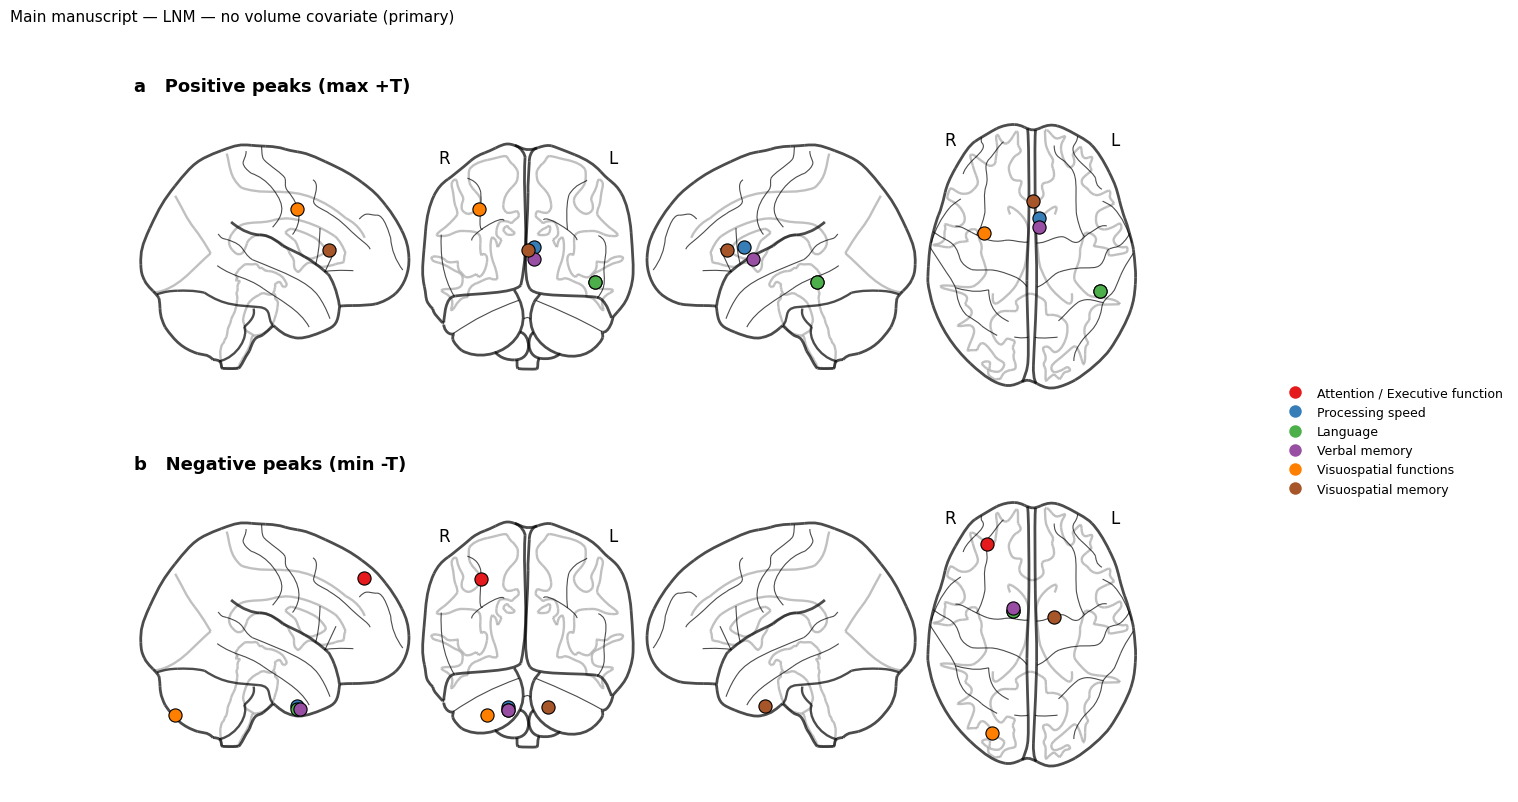

wrote output/figures/peaks_lnm_nocov_top5_positive_per_domain.png


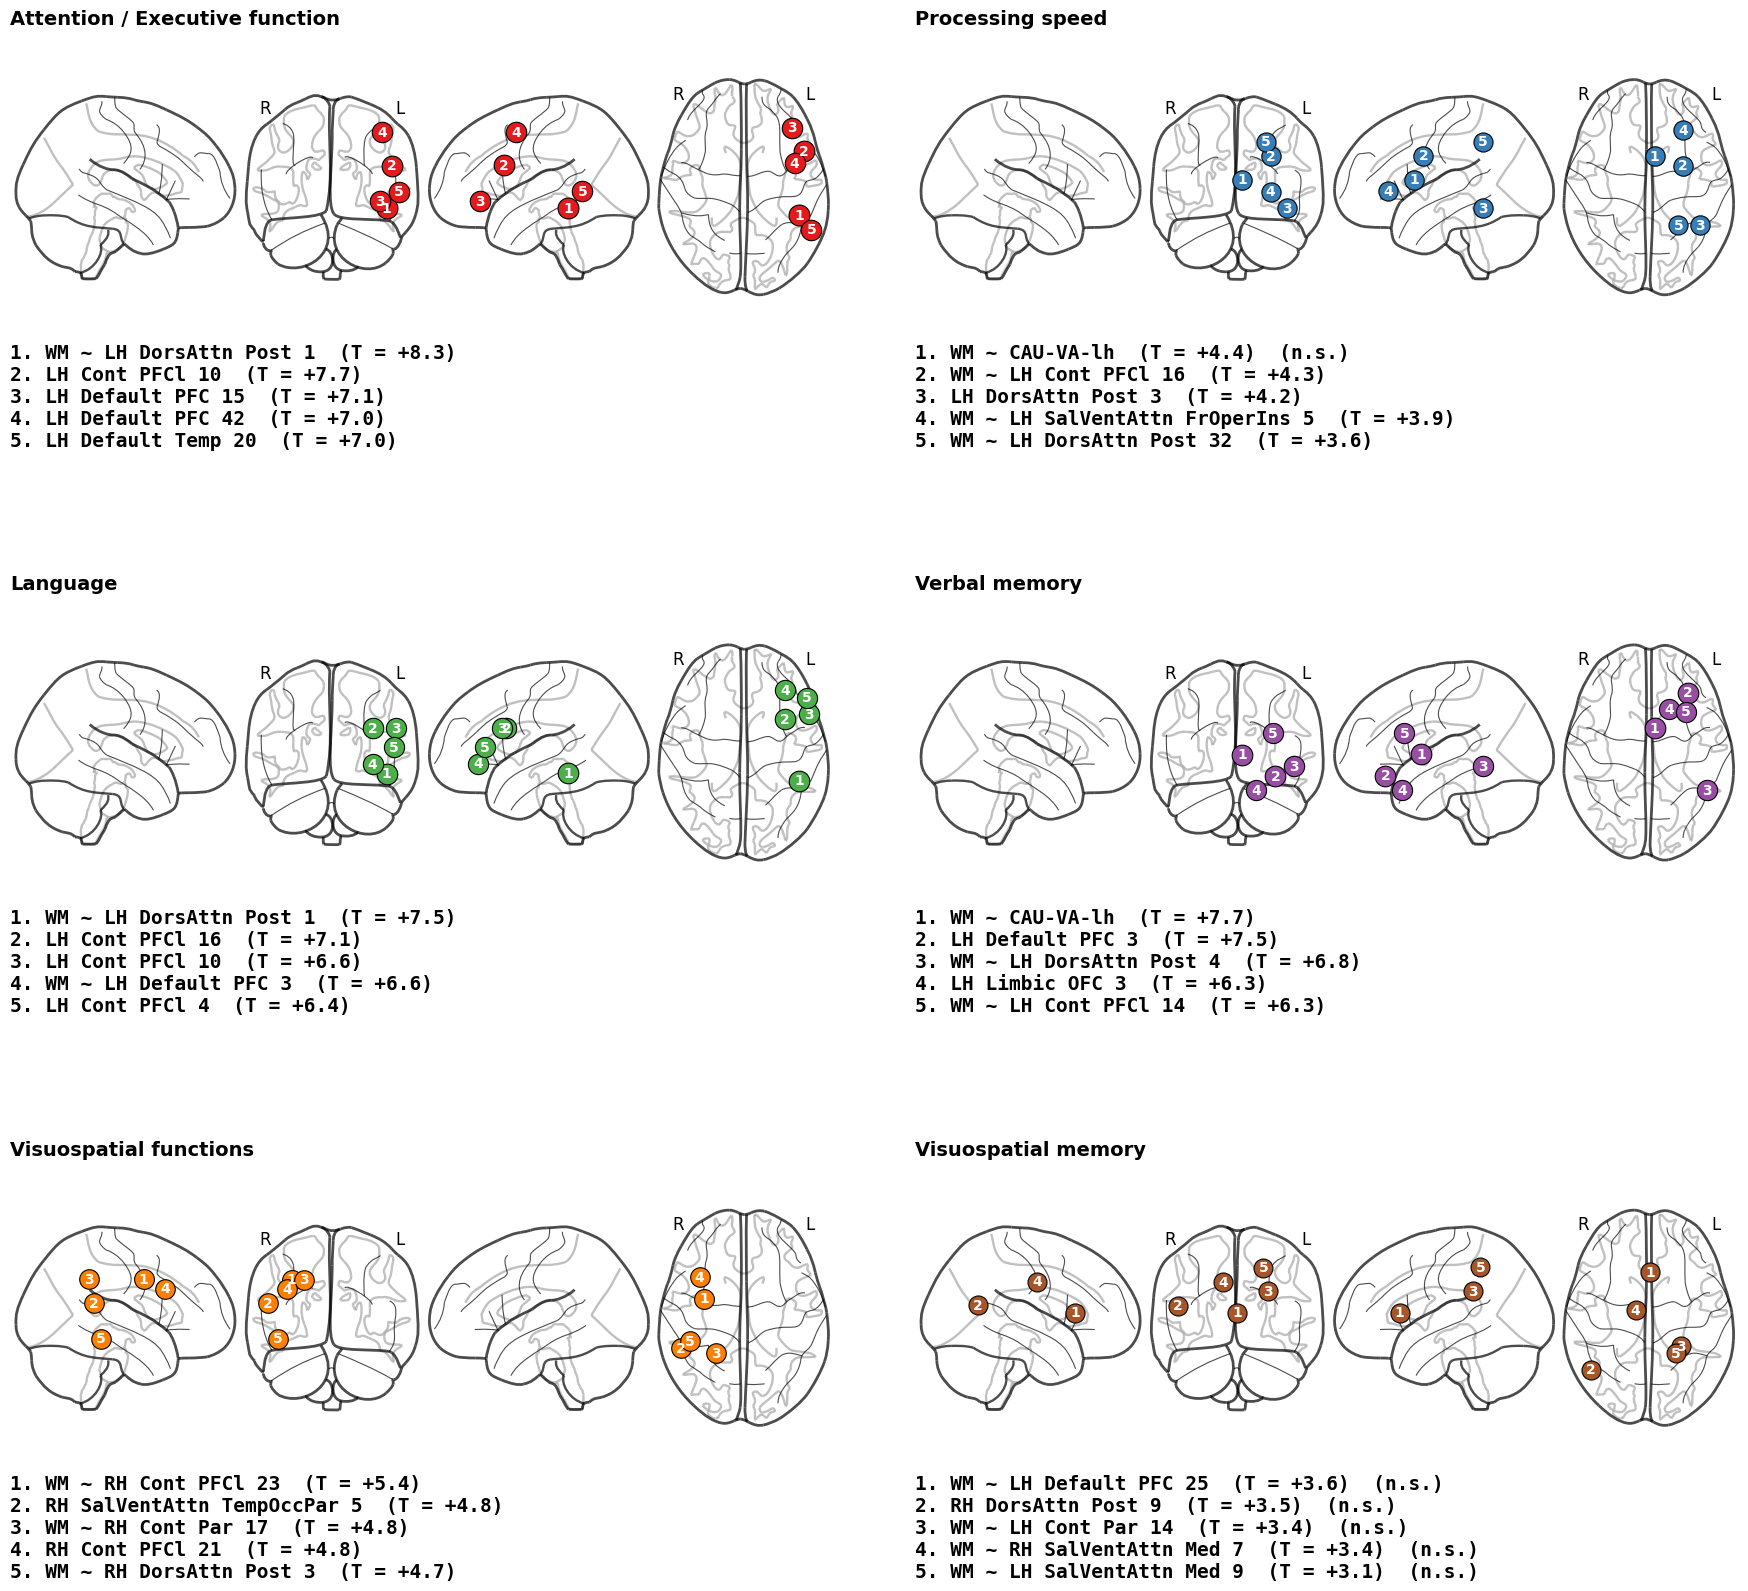

wrote output/figures/peaks_lnm_nocov_top5_negative_per_domain.png


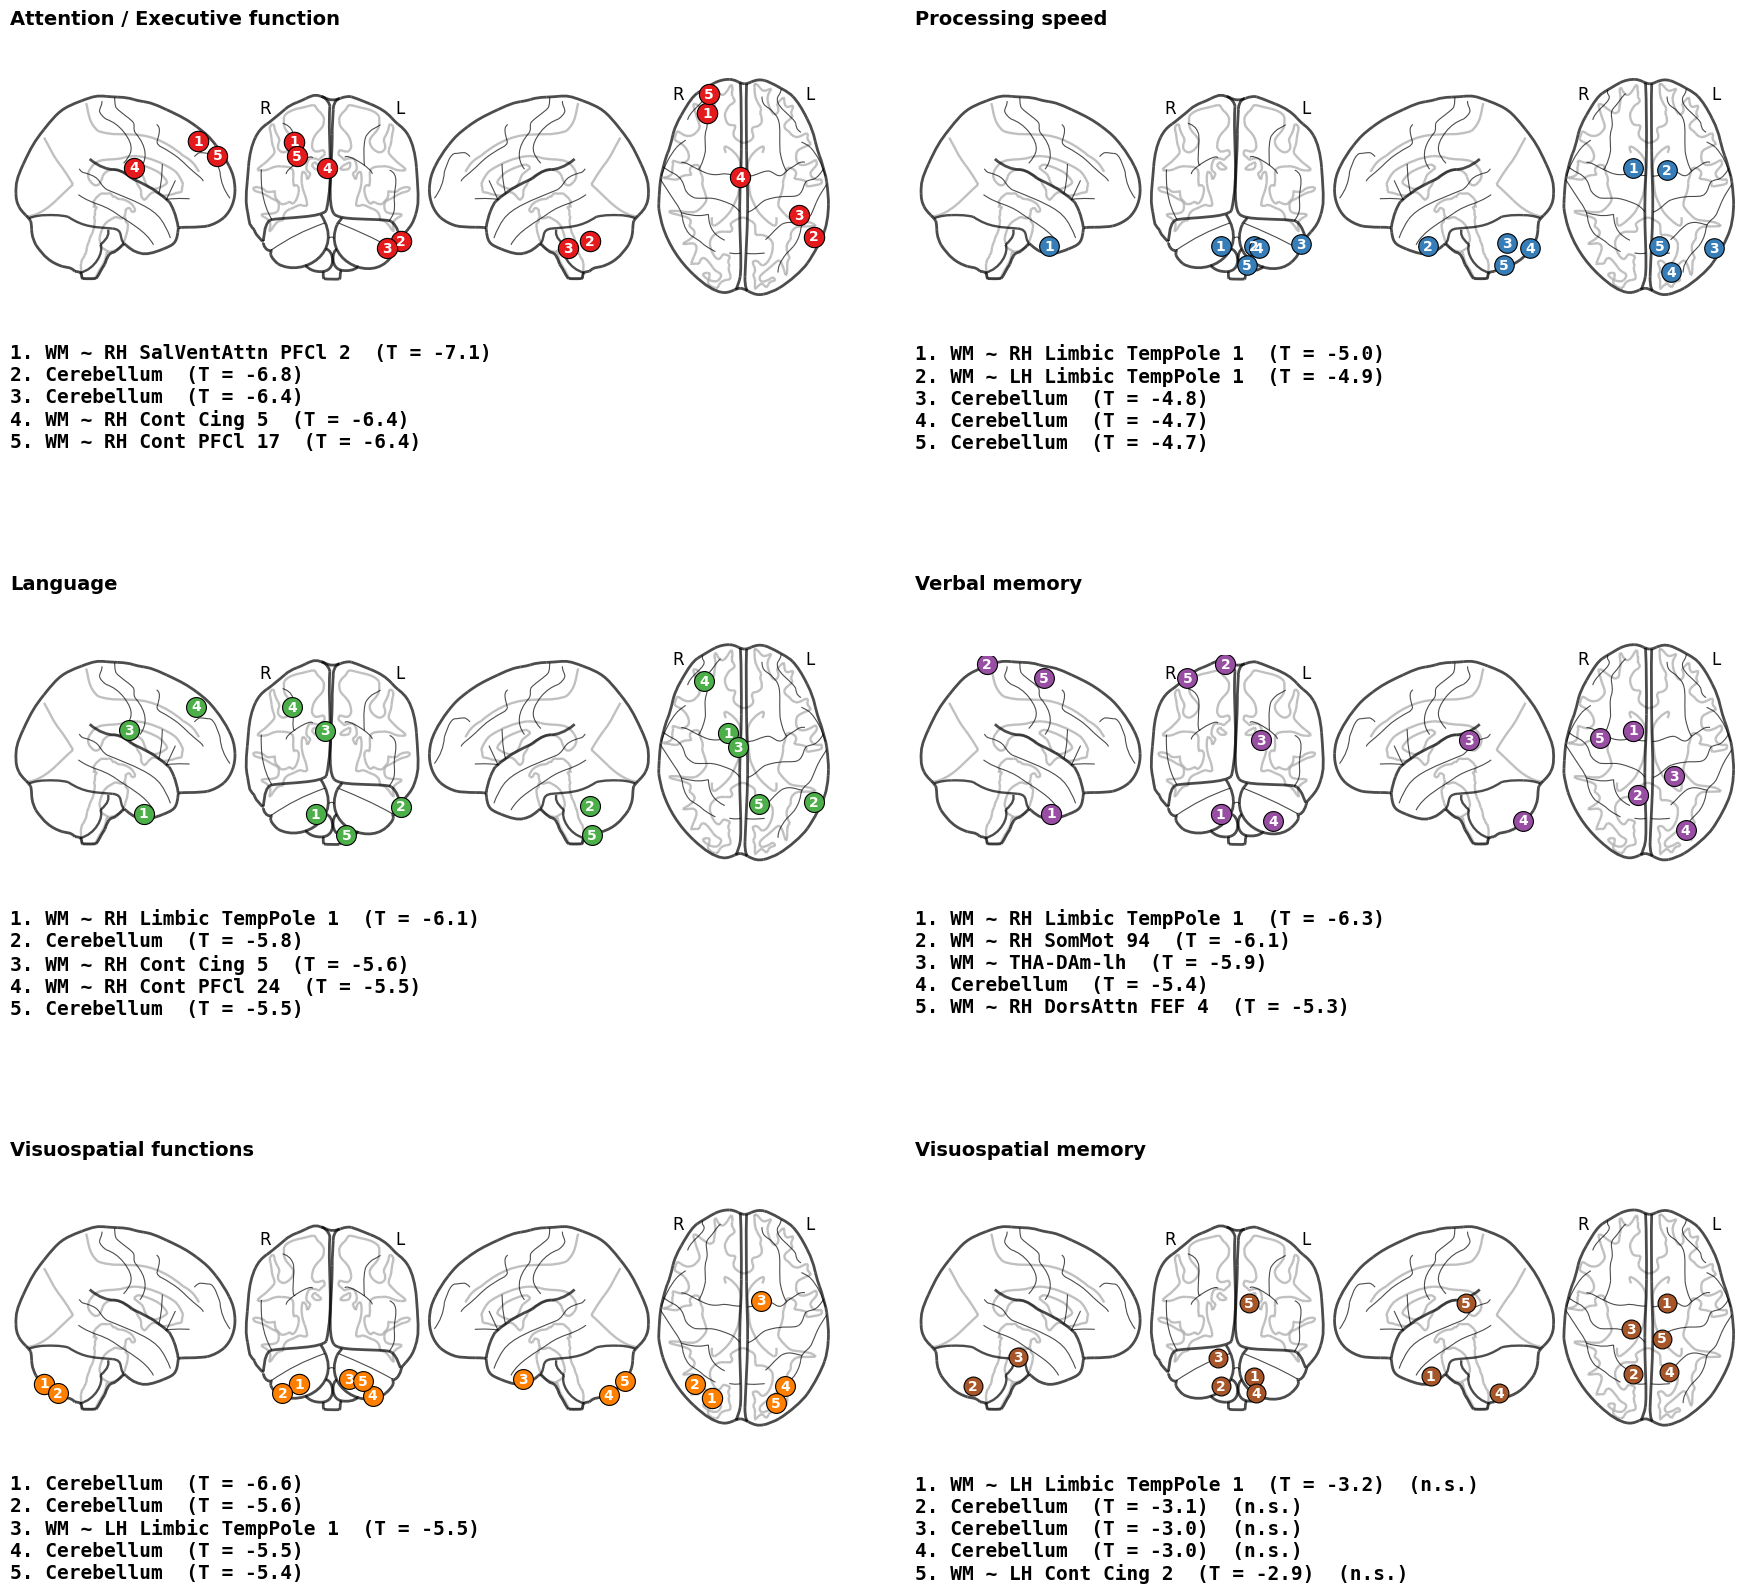

wrote output/figures/peaks_lnm_nocov_cognition-aef_domain_score.png


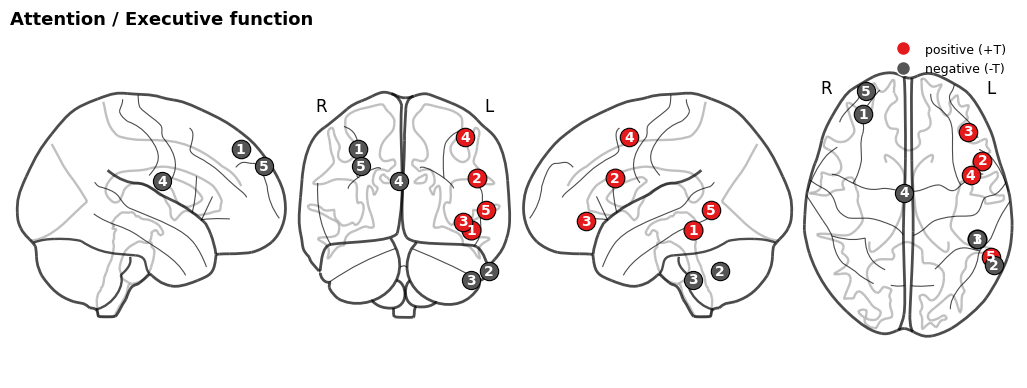

wrote output/figures/peaks_lnm_nocov_cognition-ps_domain_score.png


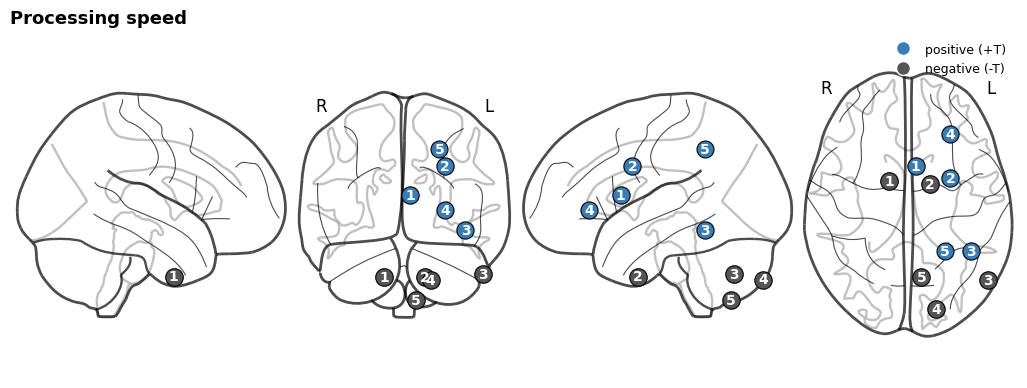

wrote output/figures/peaks_lnm_nocov_cognition-language_domain_score.png


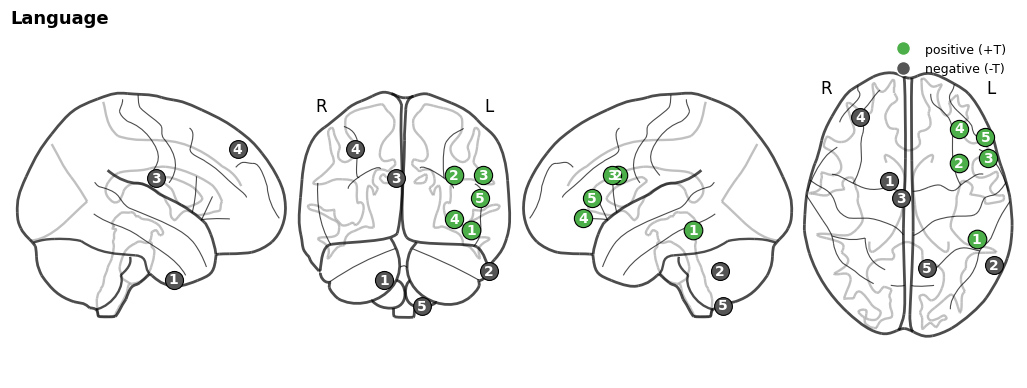

wrote output/figures/peaks_lnm_nocov_cognition-verbalmemory_domain_score.png


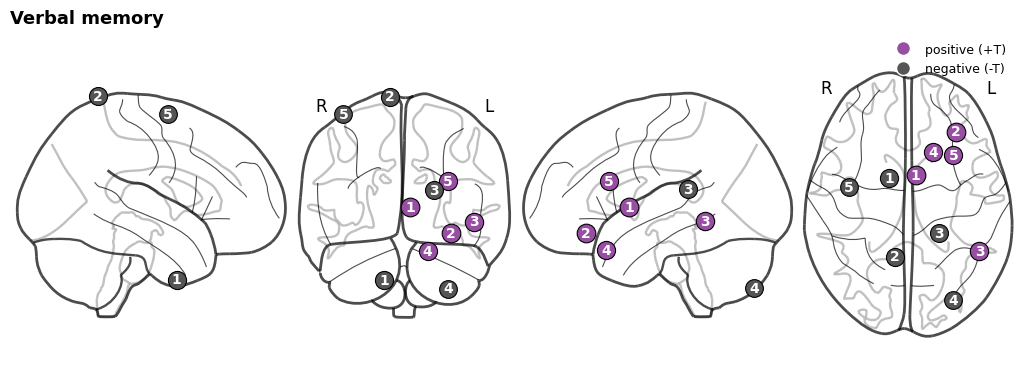

wrote output/figures/peaks_lnm_nocov_cognition-vsfunctions_domain_score.png


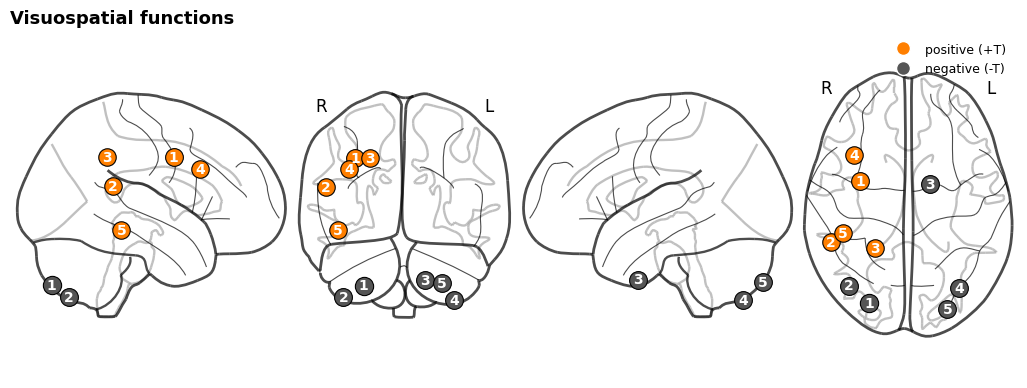

wrote output/figures/peaks_lnm_nocov_cognition-vsmemory_domain_score.png


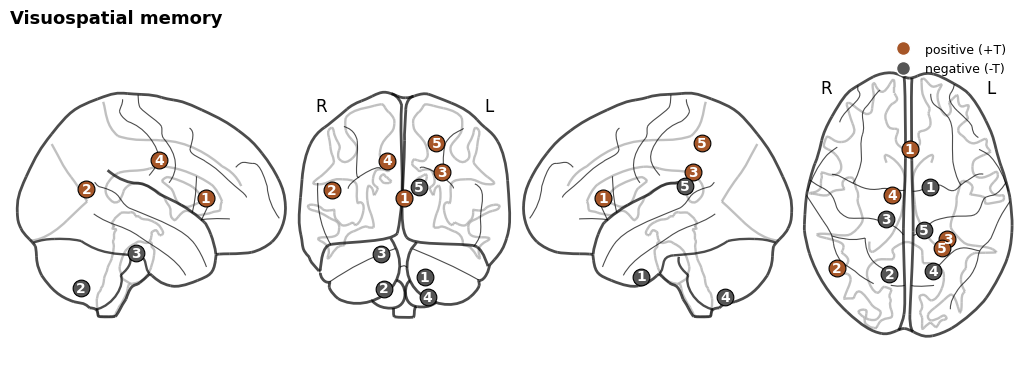

,family,domain,domain_key,sign,peak_rank,is_global_peak,significant,MNI_x,MNI_y,MNI_z,T_value,abs_T,degree_pctile,anatomical_label
0,lnm_nocov,Attention / Executive function,cognition-aef_domain_score,positive,1,True,True,-46.0,-40.0,-12.0,8.33,8.33,32.3,deep white matter (nearest: 7Networks_LH_DorsA...
1,lnm_nocov,Attention / Executive function,cognition-aef_domain_score,positive,2,False,True,-50.0,14.0,24.0,7.74,7.74,75.9,7Networks_LH_Cont_PFCl_10
2,lnm_nocov,Attention / Executive function,cognition-aef_domain_score,positive,3,False,True,-40.0,34.0,-6.0,7.10,7.10,77.6,7Networks_LH_Default_PFC_15
3,lnm_nocov,Attention / Executive function,cognition-aef_domain_score,positive,4,False,True,-42.0,4.0,52.0,7.04,7.04,73.8,7Networks_LH_Default_PFC_42
4,lnm_nocov,Attention / Executive function,cognition-aef_domain_score,positive,5,False,True,-56.0,-52.0,2.0,7.03,7.03,74.1,7Networks_LH_Default_Temp_20


In [5]:
main_table = render_family(MAIN_FAMILY)
main_table.head()